# SK-DGCNN for MARS Skeleton Estimation

This notebook implements the SK-DGCNN pose-estimation stage from Zhang et al. (2026) using its wrist-and-feet 19-joint contract. One synchronized radar point-cloud frame is transformed into centered paper-style `[x, z]` joints: lateral and vertical coordinates. The local Kinect source supplies these from native indices `(0, 1)`; Kinect `x` is inverted to align its horizontal direction with the MARS radar coordinate frame.

The input uses five radar features: `[x, y, z, velocity, intensity]`. Skeleton coordinates are normalized around the spine-shoulder center joint, without additional standardization.

Dimension convention:

- B: batch size
- C: radar feature channels, set to 5
- N: radar points per frame, set to 25
- J: skeleton joints, set to 19
- D: predicted skeleton coordinates per joint, set to 2 (`x,z`: lateral, vertical)

In [66]:
from functools import lru_cache
from pathlib import Path
import time

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import clear_output
from torch.utils.data import DataLoader, Dataset

In [67]:
PROJECT_ROOT = Path('/Users/elo/Coding/radar_ml')
DATA_ROOT = PROJECT_ROOT / 'datasets' / 'MARS'
CHECKPOINT_ROOT = PROJECT_ROOT / 'checkpoints' / 'MARS_skdgcnn'

ACTIVITY_CLASS_NAMES = (
    'Left_upper_limb_extension', 'Right_upper_limb_extension', 'Both_upper_limb_extension',
    'Left_front_lunge', 'Right_front_lunge', 'Squad', 'Left_side_lunge',
    'Right_side_lunge', 'Left_limb_extension', 'Right_limb_extension',
)
SKELETON_JOINT_NAMES = (
    'SpineBase', 'SpineMid', 'Neck', 'Head',
    'ShoulderLeft', 'ElbowLeft', 'WristLeft',
    'ShoulderRight', 'ElbowRight', 'WristRight',
    'HipLeft', 'KneeLeft', 'AnkleLeft', 'FootLeft',
    'HipRight', 'KneeRight', 'AnkleRight', 'FootRight', 'SpineShoulder',
)
SKELETON_JOINT_INDICES = (0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20)
SKELETON_COORDINATE_NAMES = ('x', 'z')  # Paper convention: horizontal and vertical
SKELETON_COORDINATE_INDICES = (0, 1)  # Native Kinect source: lateral and vertical
CENTER_JOINT_INDEX = SKELETON_JOINT_NAMES.index('SpineShoulder')
SKELETON_EDGES = ((0, 1), (1, 18), (18, 2), (2, 3), (18, 4), (4, 5), (5, 6), (18, 7), (7, 8), (8, 9), (0, 10), (10, 11), (11, 12), (12, 13), (0, 14), (14, 15), (15, 16), (16, 17))
RADAR_FEATURE_ROWS = {'x': 2, 'y': 3, 'z': 4, 'velocity': 5, 'intensity': 6}

DEVICE = 'mps'
CONFIG = {
    'feature_names': ('x', 'y', 'z', 'velocity', 'intensity'),
    'feature_amount': 5,
    'num_points': 25,
    'validation_fraction': 0.2,
    'k': 20,
    'emb_dims': 512,
    'dropout': 0.4,
    'batch_size': 16,
    'test_batch_size': 64,
    'num_epochs': 150,
    'base_lr': 0.001,
    'adam_momentum': 0.5,
    'lr_milestones': [15, 20],
    'lr_gamma': 0.1,
    'axis_order': (1, 0),
    'axis_phase_epochs': 75,
    'jitter_std': 0.01,
    'jitter_clip': 0.03,
    'translation_limit': 0.10,
    'eca_kernel_size': 3,
}

# Data

In [68]:
def paired_kinect_file_path(radar_file_path):
    "Return the Kinect file paired with one radar file."
    return Path(str(radar_file_path).replace('/radar_data', '/kinect_data'))

In [69]:
def split_file_paths():
    "Split local training recordings for validation and keep Test held out."
    train_files, valid_files = [], []
    for class_name in ACTIVITY_CLASS_NAMES:
        paths = sorted((DATA_ROOT / 'Train').glob(f'subject*/{class_name}/radar_data*.mat'))
        valid_count = max(1, int(len(paths) * CONFIG['validation_fraction']))
        valid_count = min(valid_count, len(paths) - 1)
        train_files.extend(str(path) for path in paths[:-valid_count])
        valid_files.extend(str(path) for path in paths[-valid_count:])
    test_files = [
        str(path)
        for class_name in ACTIVITY_CLASS_NAMES
        for path in sorted((DATA_ROOT / 'Test').glob(f'subject*/{class_name}/radar_data*.mat'))
    ]
    return train_files, valid_files, test_files

In [70]:
@lru_cache(maxsize=None)
def load_radar_frames_raw(file_path):
    "Load one MARS radar file as a list of raw point tensors."
    with h5py.File(file_path, 'r') as handle:
        radar = np.asarray(handle['radar_data_cropped'])
    frame_ids = radar[0].astype(np.int64)
    feature_rows = [RADAR_FEATURE_ROWS[name] for name in CONFIG['feature_names']]
    features = radar[feature_rows].T.astype(np.float32)
    return [torch.from_numpy(features[frame_ids == frame_id]) for frame_id in np.unique(frame_ids)]

In [71]:
@lru_cache(maxsize=None)
def train_radar_normalization_stats():
    "Compute radar feature normalization stats over training subjects."
    train_files, _, _ = split_file_paths()
    points = torch.cat([torch.cat(load_radar_frames_raw(path), dim=0) for path in train_files], dim=0)
    return points.mean(dim=0), points.std(dim=0).clamp_min(1e-6)

In [72]:
@lru_cache(maxsize=None)
def load_radar_frames(file_path):
    "Load one MARS radar file as normalized frame point clouds."
    mean, std = train_radar_normalization_stats()
    return [(frame - mean) / std for frame in load_radar_frames_raw(file_path)]

In [73]:
@lru_cache(maxsize=None)
def load_skeletons_raw(file_path):
    "Load one paired Kinect file as 19 two-coordinate skeleton vectors."
    skeletons = []
    with h5py.File(paired_kinect_file_path(file_path), 'r') as handle:
        refs = np.asarray(handle['kinect_data_cropped']['JointPositions']).ravel()
        for ref in refs:
            joints = np.asarray(handle[ref], dtype=np.float32)[0][:, SKELETON_JOINT_INDICES].T
            skeletons.append(torch.from_numpy(joints[:, SKELETON_COORDINATE_INDICES].reshape(-1)))
    return skeletons

In [74]:
def normalize_skeleton(skeleton):
    "Align Kinect lateral direction to radar and center the lateral, vertical skeleton."
    skeleton = skeleton.view(len(SKELETON_JOINT_INDICES), len(SKELETON_COORDINATE_NAMES)).clone()
    skeleton[:, 0] = -skeleton[:, 0]
    return (skeleton - skeleton[CENTER_JOINT_INDEX]).reshape(-1)

In [75]:
@lru_cache(maxsize=None)
def load_skeletons(file_path):
    "Load centered lateral, vertical skeleton vectors without standardization."
    return [normalize_skeleton(skeleton) for skeleton in load_skeletons_raw(file_path)]

In [76]:
def build_frame_index(file_paths):
    "Create synchronized radar-frame to skeleton-frame samples."
    samples = []
    for file_path in file_paths:
        frame_amount = min(len(load_radar_frames(file_path)), len(load_skeletons(file_path)))
        for frame_idx in range(frame_amount):
            samples.append((file_path, frame_idx))
    return samples

In [77]:
def process_frame(points):
    "Pad or crop one radar frame to a fixed-size SK-DGCNN point cloud."
    output = torch.zeros(CONFIG['num_points'], CONFIG['feature_amount'], dtype=torch.float32)
    output[:min(len(points), CONFIG['num_points'])] = points[:CONFIG['num_points']]
    return output

In [78]:
def augmentation(points):
    "Add training-only position and sensor noise to one raw radar frame."
    points = points.clone()
    points[:, :3] += torch.empty(3).uniform_(-CONFIG['translation_limit'], CONFIG['translation_limit'])
    noise = torch.randn_like(points[:, :3]) * CONFIG['jitter_std']
    points[:, :3] += noise.clamp(-CONFIG['jitter_clip'], CONFIG['jitter_clip'])
    return points

In [79]:
class MARSSkeletonDataset(Dataset):
    "Dataset returning one radar point cloud and its synchronized Kinect skeleton."
    def __init__(self, samples, augment=False):
        self.samples, self.augment = samples, augment

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, frame_idx = self.samples[idx]
        points = load_radar_frames_raw(file_path)[frame_idx]
        if self.augment:
            points = augmentation(points)
        mean, std = train_radar_normalization_stats()
        point_cloud = process_frame((points - mean) / std)
        skeleton = load_skeletons(file_path)[frame_idx]
        return point_cloud, skeleton

In [80]:
train_files, valid_files, test_files = split_file_paths()
train_samples = build_frame_index(train_files)
valid_samples = build_frame_index(valid_files)
test_samples = build_frame_index(test_files)
print(len(train_files), len(valid_files), len(test_files))
print(len(train_samples), len(valid_samples), len(test_samples))
print(train_samples[:3])

19 10 10
19665 8556 11801
[('/Users/elo/Coding/radar_ml/datasets/MARS/Train/subject2/Left_upper_limb_extension/radar_data1.mat', 0), ('/Users/elo/Coding/radar_ml/datasets/MARS/Train/subject2/Left_upper_limb_extension/radar_data1.mat', 1), ('/Users/elo/Coding/radar_ml/datasets/MARS/Train/subject2/Left_upper_limb_extension/radar_data1.mat', 2)]


In [81]:
train_data = MARSSkeletonDataset(train_samples)
x, y = train_data[0]
print(x.shape, y.shape)
print(x[:3])
print(y[:9])

torch.Size([25, 5]) torch.Size([38])
tensor([[ 0.0542,  0.2528,  0.7876,  0.7013, -0.6060],
        [ 0.0542,  0.4433,  0.7416,  0.7013, -0.6060],
        [ 0.0542,  0.3617,  0.5573, -0.6996, -0.6060]])
tensor([-3.5124e-03, -5.9870e-01, -1.0872e-03, -2.5082e-01,  8.2314e-05,
         8.0731e-02, -1.9912e-03,  2.4426e-01,  1.9164e-01])


# Architecture

In [82]:
def knn(x, k):
    "K nearest neighbor indexes from the original DGCNN implementation."
    inner = -2 * torch.matmul(x.transpose(2, 1), x)
    xx = torch.sum(x ** 2, dim=1, keepdim=True)
    pairwise_distance = -xx - inner - xx.transpose(2, 1)
    return pairwise_distance.topk(k=k, dim=-1)[1]

In [83]:
def get_graph_feature(x, k=20, idx=None):
    "Build EdgeConv features as concat(center - neighbor, center)."
    batch_size, _, num_points = x.shape
    if idx is None:
        idx = knn(x, k=k)
    idx_base = torch.arange(batch_size, device=x.device).view(-1, 1, 1) * num_points
    idx = (idx + idx_base).view(-1)
    points = x.transpose(2, 1).contiguous()
    neighbors = points.view(batch_size * num_points, -1)[idx].view(batch_size, num_points, k, -1)
    centers = points.view(batch_size, num_points, 1, -1).repeat(1, 1, k, 1)
    return torch.cat((centers - neighbors, centers), dim=3).permute(0, 3, 1, 2).contiguous()

In [84]:
class ECALayer(nn.Module):
    "Efficient channel attention for SK-DGCNN feature maps."
    def __init__(self, channels):
        super().__init__()
        kernel_size = CONFIG['eca_kernel_size']
        self.conv = nn.Conv1d(1, 1, kernel_size=kernel_size, padding=(kernel_size - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        y = x.mean(dim=tuple(range(2, x.dim()))).unsqueeze(1)
        y = self.conv(y).squeeze(1).view(x.size(0), x.size(1), *([1] * (x.dim() - 2)))
        return x * self.sigmoid(y)

In [85]:
class DGCNNSkeletonRegressor(nn.Module):
    "SK-DGCNN regressor predicting centered lateral, vertical coordinates for 19 joints."
    def __init__(self):
        super().__init__()
        self.k = CONFIG['k']
        self.joints = len(SKELETON_JOINT_INDICES)
        self.bn1 = nn.BatchNorm2d(64)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)
        self.bn4 = nn.BatchNorm1d(CONFIG['emb_dims'])
        self.bn5 = nn.BatchNorm1d(512)
        self.bn6 = nn.BatchNorm1d(self.joints * 128)
        self.conv1 = nn.Sequential(nn.Conv2d(CONFIG['feature_amount'] * 2, 64, 1, bias=False), self.bn1, nn.LeakyReLU(0.2))
        self.conv2 = nn.Sequential(nn.Conv2d(128, 64, 1, bias=False), self.bn2, nn.LeakyReLU(0.2))
        self.conv3 = nn.Sequential(nn.Conv2d(128, 128, 1, bias=False), self.bn3, nn.LeakyReLU(0.2))
        self.conv4 = nn.Sequential(nn.Conv1d(256, CONFIG['emb_dims'], 1, bias=False), self.bn4, nn.LeakyReLU(0.2))
        self.eca1, self.eca2 = ECALayer(64), ECALayer(64)
        self.eca3, self.eca4 = ECALayer(128), ECALayer(CONFIG['emb_dims'])
        self.linear1 = nn.Linear(CONFIG['emb_dims'] * 2, 512, bias=False)
        self.linear2 = nn.Linear(512, self.joints * 128, bias=False)
        self.dp1, self.dp2 = nn.Dropout(CONFIG['dropout']), nn.Dropout(CONFIG['dropout'])
        self.x_head, self.z_head = nn.Linear(128, 1), nn.Linear(128, 1)

    def forward(self, x):
        batch_size = x.size(0)
        x1 = self.eca1(self.conv1(get_graph_feature(x, self.k))).max(dim=-1)[0]
        x2 = self.eca2(self.conv2(get_graph_feature(x1, self.k))).max(dim=-1)[0]
        x3 = self.eca3(self.conv3(get_graph_feature(x2, self.k))).max(dim=-1)[0]
        x = self.eca4(self.conv4(torch.cat((x1, x2, x3), dim=1)))
        x = torch.cat((F.adaptive_max_pool1d(x, 1).view(batch_size, -1), F.adaptive_avg_pool1d(x, 1).view(batch_size, -1)), dim=1)
        x = self.dp1(F.leaky_relu(self.bn5(self.linear1(x)), negative_slope=0.2))
        x = self.dp2(F.leaky_relu(self.bn6(self.linear2(x)), negative_slope=0.2)).view(batch_size, self.joints, 128)
        return torch.cat((self.x_head(x), self.z_head(x)), dim=2).reshape(batch_size, -1)

In [86]:
model = DGCNNSkeletonRegressor()
train_loader = DataLoader(train_data, batch_size=CONFIG['batch_size'], shuffle=True, drop_last=True)
sample_batch, sample_skeletons = next(iter(train_loader))
logits = model(sample_batch.permute(0, 2, 1))
print(sample_batch.shape)
print(sample_batch.permute(0, 2, 1).shape)
print(logits.shape, sample_skeletons.shape)

torch.Size([16, 25, 5])
torch.Size([16, 5, 25])
torch.Size([16, 38]) torch.Size([16, 38])


# Training

In [87]:
def mean_absolute_error(predictions, targets):
    "Compute mean absolute lateral, vertical skeleton error in centimeters."
    return (predictions - targets).abs().mean().item() * 100

In [88]:
def mixed_loss(predictions, targets, axis, epoch):
    "Compute the paper's dynamic MSE plus KLDiv loss for one coordinate axis."
    coordinate_count = len(SKELETON_COORDINATE_NAMES)
    predictions = predictions.view(-1, len(SKELETON_JOINT_INDICES), coordinate_count)[:, :, axis]
    targets = targets.view(-1, len(SKELETON_JOINT_INDICES), coordinate_count)[:, :, axis]
    alpha_kl = 0.05 * (epoch // 20)
    alpha_mse = 1 - alpha_kl
    mse = F.mse_loss(predictions, targets)
    kldiv = F.kl_div(F.log_softmax(predictions, dim=1), F.softmax(targets, dim=1), reduction='batchmean')
    return alpha_mse * mse + alpha_kl * kldiv

In [89]:
def skeleton_loss(predictions, targets, epoch):
    "Apply sequential multitask loss in vertical z, lateral x order."
    phase = min(epoch // CONFIG['axis_phase_epochs'], len(CONFIG['axis_order']) - 1)
    return sum(mixed_loss(predictions, targets, axis, epoch) for axis in CONFIG['axis_order'][:phase + 1])

In [90]:
def create_dataloaders():
    "Create train, internal validation, and held-out test dataloaders."
    train_loader = DataLoader(MARSSkeletonDataset(train_samples, augment=True), batch_size=CONFIG['batch_size'], shuffle=True, drop_last=True)
    valid_loader = DataLoader(MARSSkeletonDataset(valid_samples), batch_size=CONFIG['test_batch_size'], shuffle=False, drop_last=False)
    test_loader = DataLoader(MARSSkeletonDataset(test_samples), batch_size=CONFIG['test_batch_size'], shuffle=False, drop_last=False)
    return train_loader, valid_loader, test_loader

In [91]:
def run_epoch(model, dataloader, epoch=0, optimizer=None):
    "Run one training or evaluation epoch."
    model.train(optimizer is not None)
    losses, grad_norms, all_predictions, all_targets = [], [], [], []
    for data, target in dataloader:
        data, target = data.to(DEVICE).permute(0, 2, 1), target.to(DEVICE)
        if optimizer is not None:
            optimizer.zero_grad()
        predictions = model(data)
        loss = skeleton_loss(predictions, target, epoch)
        if optimizer is not None:
            loss.backward()
            grad_norm = torch.sqrt(sum(p.grad.detach().pow(2).sum() for p in model.parameters() if p.grad is not None)).item()
            optimizer.step()
            grad_norms.append(grad_norm)
        losses.append(loss.item())
        all_predictions.append(predictions.detach().cpu())
        all_targets.append(target.detach().cpu())
    all_predictions, all_targets = torch.cat(all_predictions), torch.cat(all_targets)
    return losses, grad_norms, mean_absolute_error(all_predictions, all_targets)

In [92]:
def plot(train_losses, valid_losses, all_grad_norms, model_param_count, num_epochs, train_epoch_sizes, valid_epoch_sizes, epoch_means):
    "Plot the losses and the gradient norm over the training process."
    x_train = [e + i / s for e, s in enumerate(train_epoch_sizes) for i in range(s)]
    x_valid = [e + i / s for e, s in enumerate(valid_epoch_sizes) for i in range(s)]
    epoch_mean_valid_losses = [m for s, m in zip(valid_epoch_sizes, epoch_means) for _ in range(s)]
    tick_step = max(1, (num_epochs + 19) // 20)
    epoch_ticks = list(range(0, num_epochs + 1, tick_step))
    if epoch_ticks[-1] != num_epochs: epoch_ticks.append(num_epochs)
    plt.figure(figsize=(10, 10))
    ax1 = plt.subplot(2, 1, 1)
    w = max(1, int((len(train_losses) / num_epochs) * 0.1))
    train_loss_rolling = pd.Series(train_losses).rolling(window=w, center=True).mean()
    plt.plot(x_train, train_losses, label="Training Loss"); plt.plot(x_train, train_loss_rolling, label="Training Loss (Avg)", color="darkblue", linewidth=1); plt.plot(x_valid, valid_losses, label="Validation Loss", alpha=0.7); plt.plot(x_valid, epoch_mean_valid_losses, label="Val Loss (Avg)", color="red", linewidth=1, linestyle="--")
    plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend(); plt.title("Training and Validation Loss Over Epochs")
    ax1.set_xlim(0, num_epochs); ax1.set_xticks(epoch_ticks)
    loss_values = pd.Series(train_losses + valid_losses + epoch_means).dropna()
    q1, q3 = loss_values.quantile(0.25), loss_values.quantile(0.75)
    bottom, top = max(0, q1 - 1.5 * (q3 - q1)), q3 + 1.5 * (q3 - q1)
    if top < loss_values.max(): ax1.set_ylim(bottom, top + max((top - bottom) * 0.05, 1e-6))
    y_min, y_max = ax1.get_ylim()
    best_mean_val = float("inf")
    for i, mean_val in enumerate(epoch_means):
        if mean_val <= best_mean_val and y_min <= mean_val <= y_max: ax1.text(i + 0.5, mean_val, f"{mean_val:.3g}", color="red", ha="center", va="bottom", fontweight="medium", clip_on=True)
        best_mean_val = min(best_mean_val, mean_val)
    ax = plt.subplot(2, 1, 2)
    plt.plot(x_train, all_grad_norms, label="Gradient Norm", color="orange"); plt.xlabel("Epochs"); plt.ylabel("Norm"); plt.legend(); plt.title("Gradient Norm over Epochs")
    ax.set_xlim(0, num_epochs); ax.set_xticks(epoch_ticks)
    grad_values = pd.Series(all_grad_norms).dropna()
    q1, q3 = grad_values.quantile(0.25), grad_values.quantile(0.75)
    bottom, top = max(0, q1 - 1.5 * (q3 - q1)), q3 + 1.5 * (q3 - q1)
    if top < grad_values.max(): ax.set_ylim(bottom, top + max((top - bottom) * 0.05, 1e-6))
    ax.text(0.99, 0.02, f"Params count: {model_param_count:,}", transform=ax.transAxes, ha="right", va="bottom", fontsize=9, color="dimgray")
    plt.subplots_adjust(hspace=0.35); plt.show()

In [ ]:
def train_model(num_epochs=CONFIG['num_epochs']):
    "Launch the training process of the SK-DGCNN skeleton regressor."
    print('Training process starting...', flush=True)
    CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)
    model = DGCNNSkeletonRegressor().to(DEVICE)
    model_param_count = sum(p.numel() for p in model.parameters())
    train_loader, valid_loader, _ = create_dataloaders()
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['base_lr'], betas=(CONFIG['adam_momentum'], 0.999), weight_decay=0)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=CONFIG['lr_milestones'], gamma=CONFIG['lr_gamma'])
    train_losses, valid_losses, all_grad_norms = [], [], []
    train_epoch_sizes, valid_epoch_sizes, epoch_means = [], [], []
    best_valid_joint_distance_error = float('inf')

    for epoch in range(num_epochs):
        if epoch == CONFIG['axis_phase_epochs']:
            optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['base_lr'], betas=(CONFIG['adam_momentum'], 0.999), weight_decay=0)
            scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=CONFIG['lr_milestones'], gamma=CONFIG['lr_gamma'])
            print('Reset optimizer and scheduler for x,z training phase', flush=True)
        start = time.time()
        axis_names = [SKELETON_COORDINATE_NAMES[i] for i in CONFIG['axis_order'][:min(epoch // CONFIG['axis_phase_epochs'], 2) + 1]]
        print(f'Epoch n°{epoch} Training axes {axis_names} ====', flush=True)
        loss_list, grad_norms, train_joint_distance_error = run_epoch(model, train_loader, epoch, optimizer)
        train_losses.extend(loss_list); train_epoch_sizes.append(len(loss_list)); all_grad_norms.extend(grad_norms)

        torch.save(model.state_dict(), CHECKPOINT_ROOT / f'checkpoint_{epoch:02d}.pt')

        print(f'Epoch n°{epoch} Validation ====', flush=True)
        with torch.no_grad():
            loss_list, _, valid_joint_distance_error = run_epoch(model, valid_loader, epoch)
        valid_losses.extend(loss_list); valid_epoch_sizes.append(len(loss_list))

        mean_val = sum(loss_list) / len(loss_list)
        epoch_means.append(mean_val)
        if valid_joint_distance_error <= best_valid_joint_distance_error:
            best_valid_joint_distance_error = valid_joint_distance_error
            torch.save(model.state_dict(), CHECKPOINT_ROOT / 'model.pt')
        scheduler.step()
        clear_output(wait=True)
        print('Training process starting...', flush=True)
        print(f'Epoch n°{epoch} complete | Train joint distance error: {train_joint_distance_error:.4f} | Validation loss: {mean_val:.4f} | Validation joint distance error: {valid_joint_distance_error:.4f} | Time: {time.time() - start:.1f}s', flush=True)
        plot(train_losses, valid_losses, all_grad_norms, model_param_count, num_epochs, train_epoch_sizes, valid_epoch_sizes, epoch_means)

    return model

In [ ]:
train_model(200)

# Inference

In [93]:
def evaluate_validation_checkpoint(checkpoint_path):
    "Score a checkpoint on the internal validation split."
    model = DGCNNSkeletonRegressor().to(DEVICE)
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE, weights_only=True))
    model.eval()
    _, valid_loader, _ = create_dataloaders()
    with torch.no_grad():
        losses, _, mae = run_epoch(model, valid_loader, CONFIG['num_epochs'] - 1)
    return sum(losses) / len(losses), mae

In [30]:
checkpoint_paths = sorted(CHECKPOINT_ROOT.glob('checkpoint_*.pt'), key=lambda path: int(path.stem.split('_')[-1]))
metrics = [evaluate_validation_checkpoint(path) for path in checkpoint_paths]
checkpoint_numbers = [int(path.stem.split('_')[-1]) for path in checkpoint_paths]
validation_losses = [metric[0] for metric in metrics]
validation_maes = [metric[1] for metric in metrics]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(checkpoint_numbers, validation_maes, marker='o', label='Validation MAE')
tick_step = max(1, (len(checkpoint_numbers) + 14) // 15)
ticks = checkpoint_numbers[::tick_step]
ax.set_xticks(ticks, [f'checkpoint_{number:02d}' for number in ticks], rotation=45, ha='right')
ax.set_xlim(checkpoint_numbers[0] - 0.5, checkpoint_numbers[-1] + 0.5)
ax.set_xlabel('Checkpoint'); ax.set_ylabel('MAE (cm)'); ax.set_title('Validation MAE by checkpoint')
ax.legend(); fig.tight_layout(); plt.show()

KeyboardInterrupt: 

In [94]:
def per_joint_mean_absolute_error(model, dataloader):
    "Compute test lateral, vertical MAE in centimeters for each skeleton joint."
    predictions, targets = [], []
    with torch.no_grad():
        for data, target in dataloader:
            predictions.append(model(data.to(DEVICE).permute(0, 2, 1)).cpu())
            targets.append(target)
    errors = (torch.cat(predictions) - torch.cat(targets)).abs().view(-1, len(SKELETON_JOINT_NAMES), len(SKELETON_COORDINATE_NAMES)).mean(dim=(0, 2)) * 100
    return dict(zip(SKELETON_JOINT_NAMES, errors.tolist()))

In [95]:
model_path = PROJECT_ROOT / 'datasets/SKradHAR/checkpoint_133.pt'
model = DGCNNSkeletonRegressor().to(DEVICE)
model.load_state_dict(torch.load(model_path, map_location=DEVICE, weights_only=True))
model.eval()
_, _, test_loader = create_dataloaders()
with torch.no_grad():
    test_losses, _, test_mae = run_epoch(model, test_loader, CONFIG['num_epochs'] - 1)
test_joint_maes = per_joint_mean_absolute_error(model, test_loader)
print(f'Final model: {model_path.name}')
print(f'Test MAE: {test_mae:.4f} cm \n')
print('Test MAE per joint (cm):')
for joint_name, mae in test_joint_maes.items():
    print(f'{joint_name}: {mae:.4f}')

Final model: checkpoint_133.pt
Test MAE: 8.7298 cm 

Test MAE per joint (cm):
SpineBase: 5.0539
SpineMid: 2.1956
Neck: 0.7020
Head: 2.2504
ShoulderLeft: 2.5670
ElbowLeft: 8.9381
WristLeft: 15.4946
ShoulderRight: 2.9307
ElbowRight: 9.0740
WristRight: 15.7876
HipLeft: 5.4562
KneeLeft: 11.3033
AnkleLeft: 16.4269
FootLeft: 17.4723
HipRight: 5.5735
KneeRight: 11.4106
AnkleRight: 16.0639
FootRight: 16.9049
SpineShoulder: 0.2605


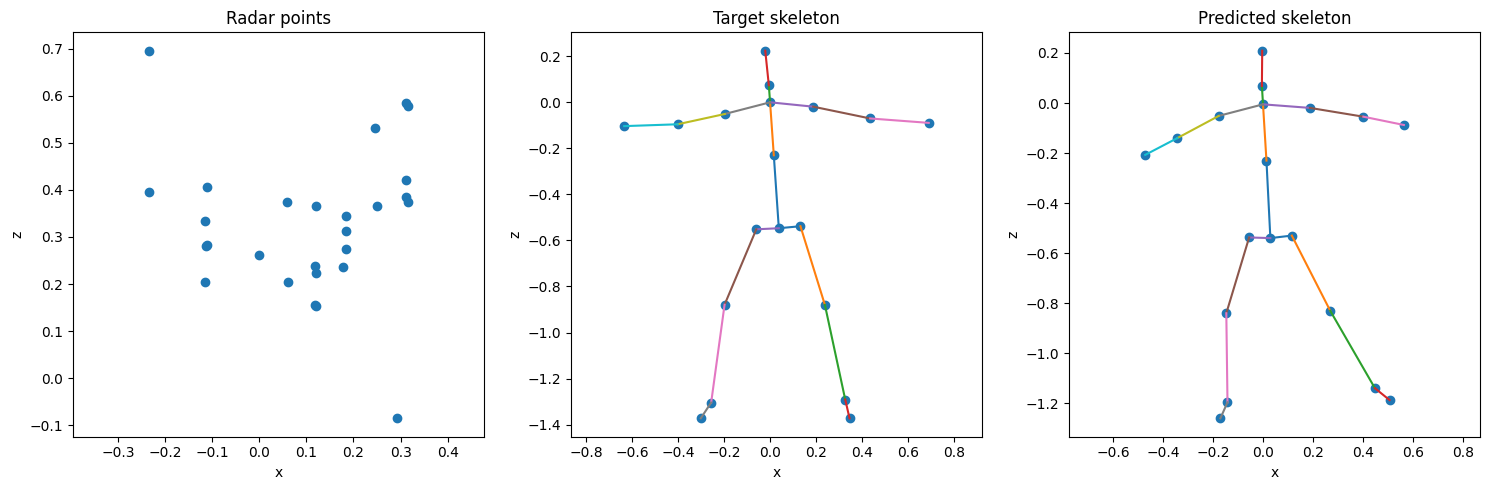

In [126]:
sample_idx = torch.randint(len(test_samples), (1,)).item()
file_path, frame_idx = test_samples[sample_idx]
radar_points = load_radar_frames_raw(file_path)[frame_idx][:, [0, 2]].numpy()
point_cloud, target = MARSSkeletonDataset(test_samples)[sample_idx]

with torch.no_grad():
    prediction = model(point_cloud.unsqueeze(0).to(DEVICE).permute(0, 2, 1)).cpu()[0]
prediction = prediction.view(len(SKELETON_JOINT_INDICES), len(SKELETON_COORDINATE_NAMES)).numpy()
target = target.view(len(SKELETON_JOINT_INDICES), len(SKELETON_COORDINATE_NAMES)).numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].scatter(radar_points[:, 0], radar_points[:, 1]); axes[0].set_title('Radar points')
for ax, skeleton, title in zip(axes[1:], (target, prediction), ('Target skeleton', 'Predicted skeleton')):
    ax.scatter(skeleton[:, 0], skeleton[:, 1])
    for start, end in SKELETON_EDGES:
        ax.plot(skeleton[[start, end], 0], skeleton[[start, end], 1])
    ax.set_title(title)
for ax in axes:
    ax.set_xlabel('x'); ax.set_ylabel('z'); ax.axis('equal')
plt.tight_layout(); plt.show()